## TEAM KARTHIKEYA
## Customer Churn Prediction Using Basic Data Mining Algorithms


---
### Algorithms Used 

1. **Naive Bayes** — Probabilistic classifier
2. **K-Nearest Neighbors (KNN)** — Instance-based learning
3. **Decision Tree** — Rule-based classifier (C4.5)
4. **Apriori-style Association** — Frequent pattern mining on churn attributes

---
## STEP 1 — Import Libraries

In [16]:
# Basic libraries only — no xgboost, no imbalanced-learn needed
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

# Preprocessing
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# ── BASIC DATA MINING ALGORITHMS ──────────────────────────────────────────────
from sklearn.naive_bayes   import GaussianNB            # Algorithm 1: Naive Bayes
from sklearn.neighbors     import KNeighborsClassifier  # Algorithm 2: KNN
from sklearn.tree          import DecisionTreeClassifier, plot_tree  # Algorithm 3: Decision Tree

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


---
## STEP 2 — Load & Explore Dataset

In [17]:
# ── Load Data ─────────────────────────────────────────────────────────────────
# Place WA_Fn-UseC_-Telco-Customer-Churn.csv in the same folder as this notebook
df = pd.read_csv("C:/Users/KARTHIKEYA/Desktop/DATA MINING\WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("=" * 55)
print("  DATASET LOADED")
print("=" * 55)
print(f"  Rows      : {df.shape[0]:,}")
print(f"  Columns   : {df.shape[1]}")
print("=" * 55)
df.head()

  DATASET LOADED
  Rows      : 7,043
  Columns   : 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
# ── Basic Info ────────────────────────────────────────────────────────────────
print("Column Names and Data Types:")
print("-" * 40)
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Column Names and Data Types:
----------------------------------------
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
Str

In [19]:
# ── Basic Statistics ──────────────────────────────────────────────────────────
print("Basic Statistical Summary:")
df.describe()

Basic Statistical Summary:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


---
## STEP 3 — Exploratory Data Analysis (EDA)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


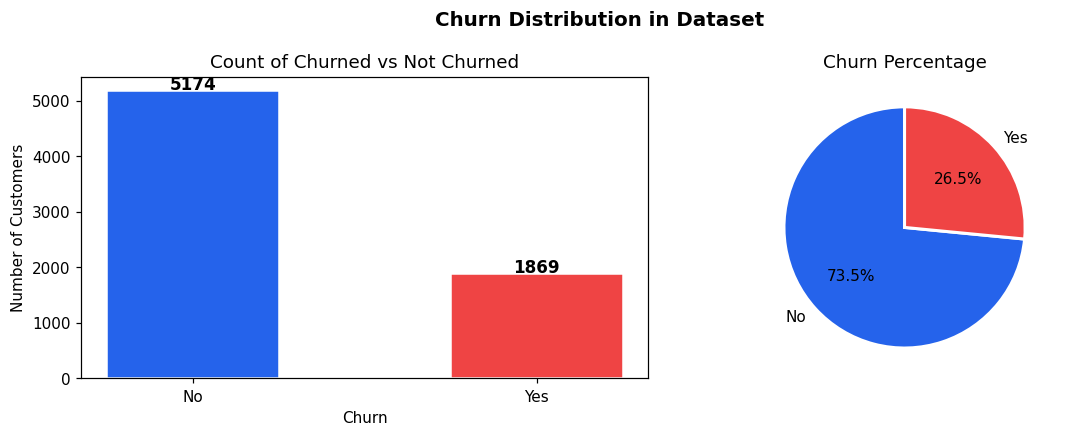

  Churn Rate = 26.54% — Dataset is IMBALANCED


In [20]:
# ── 3.1 Churn Distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Churn Distribution in Dataset', fontsize=13, fontweight='bold')

counts = df['Churn'].value_counts()
print(counts)
# Bar
axes[0].bar(counts.index, counts.values, color=['#2563EB','#EF4444'], edgecolor='white', width=0.5)
axes[0].set_title('Count of Churned vs Not Churned')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 40, str(v), ha='center', fontweight='bold', fontsize=11)

# Pie
axes[1].pie(counts.values, labels=counts.index,
            autopct='%1.1f%%', colors=['#2563EB','#EF4444'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Churn Percentage')

plt.tight_layout()
plt.show()

churn_pct = counts['Yes'] / len(df) * 100
print(f"  Churn Rate = {churn_pct:.2f}% — Dataset is IMBALANCED")

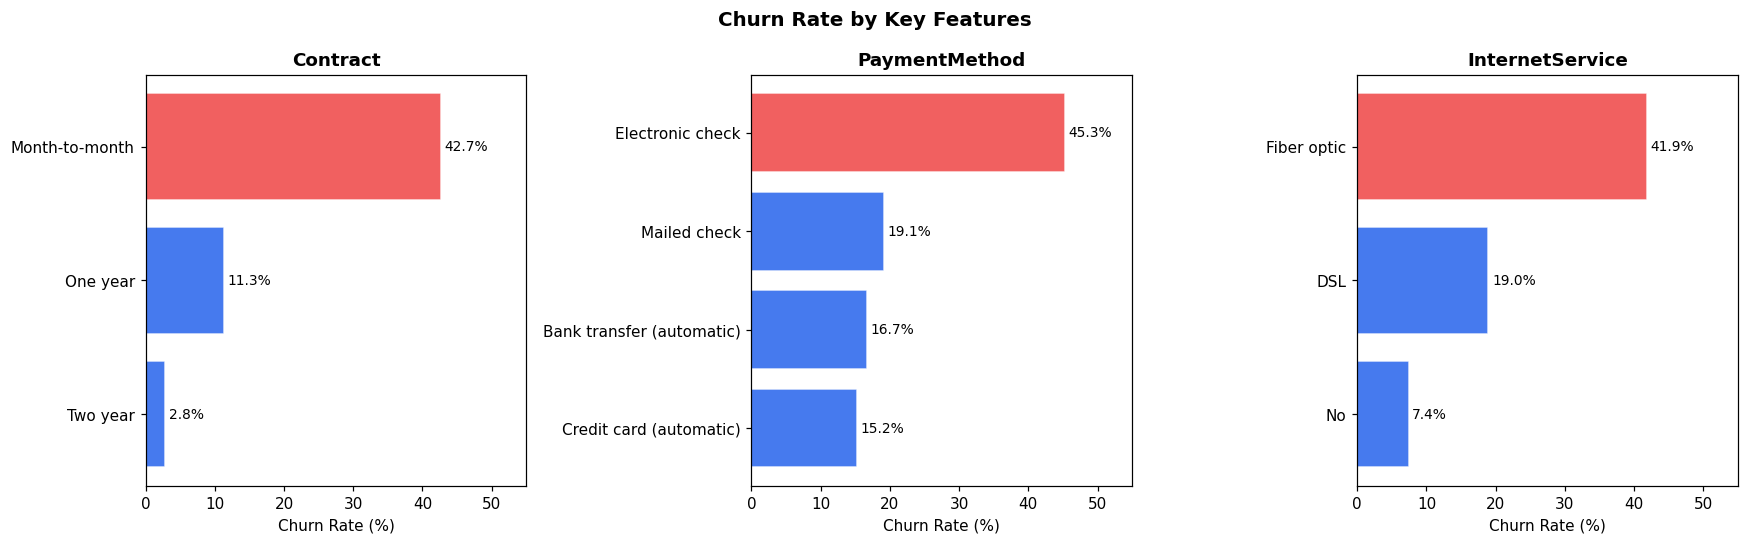

In [21]:
# ── 3.2 Churn by Contract, Payment Method, Internet Service ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Churn Rate by Key Features', fontsize=13, fontweight='bold')

features = ['Contract', 'PaymentMethod', 'InternetService']
for ax, feat in zip(axes, features):
    rate = df.groupby(feat)['Churn'].apply(lambda x: (x=='Yes').mean()*100)
    rate = rate.sort_values(ascending=True)
    colors = ['#EF4444' if v > 25 else '#2563EB' for v in rate.values]
    ax.barh(rate.index, rate.values, color=colors, edgecolor='white', alpha=0.85)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Churn Rate (%)')
    ax.set_xlim(0, 55)
    for i, v in enumerate(rate.values):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

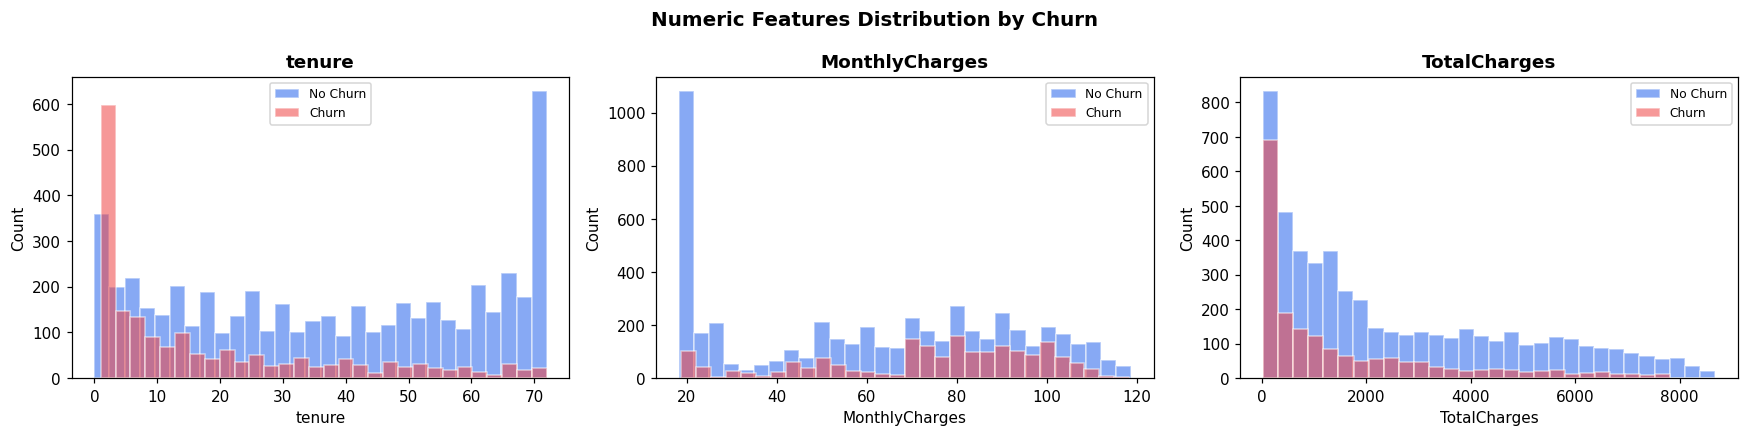

In [22]:
# ── 3.3 Numeric Feature Distributions ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Numeric Features Distribution by Churn', fontsize=13, fontweight='bold')

feats = ['tenure', 'MonthlyCharges', 'TotalCharges']
for ax, feat in zip(axes, feats):
    for grp, color, label in zip(['No','Yes'], ['#2563EB','#EF4444'], ['No Churn','Churn']):
        data = df[df['Churn'] == grp][feat]
        # TotalCharges needs to be numeric
        data = pd.to_numeric(data, errors='coerce').dropna()
        ax.hist(data, bins=30, alpha=0.55, color=color, label=label, edgecolor='white')
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

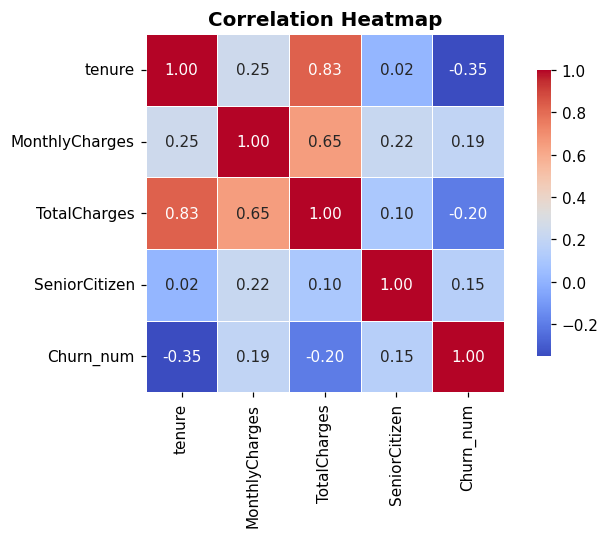

In [23]:
# ── 3.4 Correlation Heatmap ───────────────────────────────────────────────────
df_temp = df.copy()
df_temp['TotalCharges'] = pd.to_numeric(df_temp['TotalCharges'], errors='coerce')
df_temp['Churn_num'] = (df_temp['Churn'] == 'Yes').astype(int)
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_num']

plt.figure(figsize=(7, 5))
corr = df_temp[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink':0.8})
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

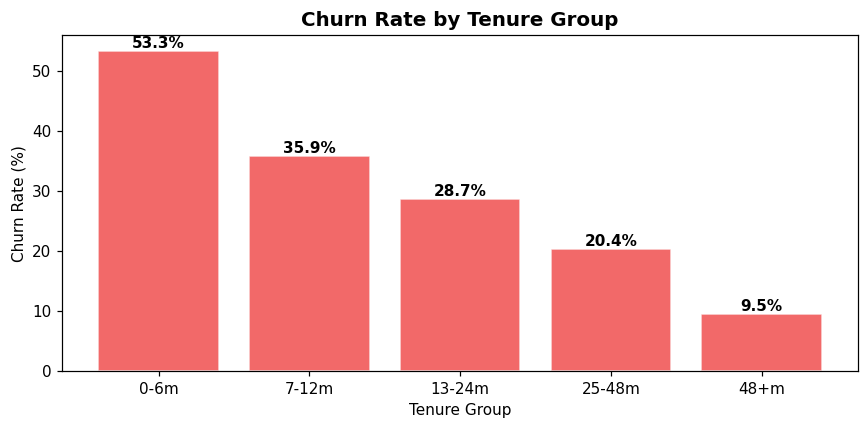

In [24]:
# ── 3.5 Tenure buckets churn rate ─────────────────────────────────────────────
df_temp['tenure_group'] = pd.cut(df_temp['tenure'],
    bins=[0,6,12,24,48,72], labels=['0-6m','7-12m','13-24m','25-48m','48+m'])

bucket_churn = df_temp.groupby('tenure_group')['Churn_num'].mean() * 100

plt.figure(figsize=(8, 4))
bars = plt.bar(bucket_churn.index, bucket_churn.values,
               color='#EF4444', alpha=0.80, edgecolor='white')
plt.title('Churn Rate by Tenure Group', fontsize=13, fontweight='bold')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
for bar, v in zip(bars, bucket_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## STEP 4 — Data Preprocessing & ETL (Extract Transform Load)

In [25]:
# ── 4.1 ETL: EXTRACT — load fresh copy ───────────────────────────────────────
data = pd.read_csv("C:\\Users\\KARTHIKEYA\\Desktop\\DATA MINING\\WA_Fn-UseC_-Tel" \
"co-Customer-Churn.csv")
print("EXTRACT → Raw shape:", data.shape)

# ── 4.2 ETL: TRANSFORM — clean & encode ──────────────────────────────────────
print("\nTRANSFORM steps:")

# Drop customerID
data.drop('customerID', axis=1, inplace=True)
print("  [1] Dropped customerID")

# Fix TotalCharges: spaces to NaN, then fill with median
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'].str.strip(), errors='coerce')
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)
print("  [2] TotalCharges cleaned — blanks filled with median")

# Encode target: Yes=1, No=0
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})
print("  [3] Churn encoded → Yes=1, No=0")

# Replace 'No phone service' and 'No internet service' → 'No'
data.replace({'No phone service': 'No', 'No internet service': 'No'}, inplace=True)
print("  [4] Standardised: 'No phone/internet service' → 'No'")

# Encode all object columns using LabelEncoder
le = LabelEncoder()
cat_cols = data.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])
print(f"  [5] Label encoded {len(cat_cols)} categorical columns: {cat_cols}")

print("\n✅ TRANSFORM complete. Shape:", data.shape)
print("\nSample (first 3 rows after encoding):")
data.head(3)

EXTRACT → Raw shape: (7043, 21)

TRANSFORM steps:
  [1] Dropped customerID
  [2] TotalCharges cleaned — blanks filled with median
  [3] Churn encoded → Yes=1, No=0
  [4] Standardised: 'No phone/internet service' → 'No'
  [5] Label encoded 15 categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

✅ TRANSFORM complete. Shape: (7043, 20)

Sample (first 3 rows after encoding):


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,1,0,1,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,1,1,0,0,0,0,0,1,3,53.85,108.15,1


In [26]:
# ── 4.3 ETL: LOAD — simulate loading to warehouse (show schema) ───────────────
import sqlite3

conn = sqlite3.connect(':memory:')  # in-memory warehouse
data.to_sql('FACT_CHURN', conn, index=False, if_exists='replace')

# Verify OLAP query
q = pd.read_sql_query(
    "SELECT Contract, COUNT(*) as customers, "
    "SUM(Churn) as churned, "
    "ROUND(SUM(Churn)*100.0/COUNT(*),2) as churn_pct "
    "FROM FACT_CHURN GROUP BY Contract ORDER BY churn_pct DESC",
    conn
)
print("ETL: LOAD → Warehouse query result (Churn by Contract):")
print(q.to_string(index=False))
conn.close()

ETL: LOAD → Warehouse query result (Churn by Contract):
 Contract  customers  churned  churn_pct
        0       3875     1655      42.71
        1       1473      166      11.27
        2       1695       48       2.83


In [27]:
# ── 4.4 Feature & Target Split + Normalisation ────────────────────────────────
X = data.drop('Churn', axis=1)
y = data['Churn']

# Normalise using MinMaxScaler (important for KNN and Naive Bayes)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Train / Test split (80:20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print("Feature Matrix (X) shape    :", X_scaled.shape)
print("Train set                   :", X_train.shape)
print("Test  set                   :", X_test.shape)
print(f"Train churn rate            : {y_train.mean()*100:.1f}%")
print(f"Test  churn rate            : {y_test.mean()*100:.1f}%")

Feature Matrix (X) shape    : (7043, 19)
Train set                   : (5634, 19)
Test  set                   : (1409, 19)
Train churn rate            : 26.5%
Test  churn rate            : 26.5%


---
## STEP 5 — Data Warehousing: Star Schema

In [28]:
# ── Star Schema Diagram (Text) ────────────────────────────────────────────────
schema = """
  ╔══════════════════════════════════╗
  ║      STAR SCHEMA DESIGN          ║
  ╠══════════════════════════════════╣

  DIM_CUSTOMER          DIM_CONTRACT
  ─────────────         ─────────────────
  customerID (PK)       contract_key (PK)
  gender                ContractType
  SeniorCitizen         PaymentMethod
  Partner               PaperlessBilling
  Dependents
  tenure
       \                    /
        ──────────────────────
        FACT_CUSTOMER_ACTIVITY    ◄── DIM_SERVICE
        ──────────────────────         PhoneService
        activity_key (PK)              MultipleLines
        customer_key (FK)              InternetService
        contract_key (FK)              OnlineSecurity
        MonthlyCharges                 OnlineBackup
        TotalCharges                   TechSupport
        churn_flag  ◄── TARGET
        ──────────────────────
"""
print(schema)


  ╔══════════════════════════════════╗
  ║      STAR SCHEMA DESIGN          ║
  ╠══════════════════════════════════╣

  DIM_CUSTOMER          DIM_CONTRACT
  ─────────────         ─────────────────
  customerID (PK)       contract_key (PK)
  gender                ContractType
  SeniorCitizen         PaymentMethod
  Partner               PaperlessBilling
  Dependents
  tenure
       \                    /
        ──────────────────────
        FACT_CUSTOMER_ACTIVITY    ◄── DIM_SERVICE
        ──────────────────────         PhoneService
        activity_key (PK)              MultipleLines
        customer_key (FK)              InternetService
        contract_key (FK)              OnlineSecurity
        MonthlyCharges                 OnlineBackup
        TotalCharges                   TechSupport
        churn_flag  ◄── TARGET
        ──────────────────────



In [37]:
# ── Build Star Schema in SQLite ───────────────────────────────────────────────
raw = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
raw['TotalCharges'] = pd.to_numeric(raw['TotalCharges'].str.strip(), errors='coerce')
raw['TotalCharges'].fillna(raw['TotalCharges'].median(), inplace=True)
raw['churn_flag'] = (raw['Churn'] == 'Yes').astype(int)

conn = sqlite3.connect('churn_warehouse.db')

# DIM_CUSTOMER
raw[['customerID','gender','SeniorCitizen','Partner','Dependents','tenure']]\
    .to_sql('DIM_CUSTOMER', conn, if_exists='replace', index=False)

# DIM_CONTRACT
raw[['customerID','Contract','PaymentMethod','PaperlessBilling']]\
    .rename(columns={'Contract':'ContractType'})\
    .to_sql('DIM_CONTRACT', conn, if_exists='replace', index=False)

# DIM_SERVICE
raw[['customerID','PhoneService','MultipleLines','InternetService',
     'OnlineSecurity','OnlineBackup','TechSupport','StreamingTV','StreamingMovies']]\
    .to_sql('DIM_SERVICE', conn, if_exists='replace', index=False)

# FACT TABLE
raw[['customerID','MonthlyCharges','TotalCharges','churn_flag']]\
    .to_sql('FACT_CUSTOMER_ACTIVITY', conn, if_exists='replace', index=False)

conn.commit()
print("✅ Star Schema Data Warehouse built: churn_warehouse.db")

# OLAP Query: Revenue at risk
q = pd.read_sql_query(
    "SELECT ROUND(SUM(MonthlyCharges),2) as revenue_at_risk "
    "FROM FACT_CUSTOMER_ACTIVITY WHERE churn_flag=1", conn
)


# OLAP Query: Churn by contract
q2 = pd.read_sql_query(
    "SELECT c.ContractType, COUNT(*) as customers, SUM(f.churn_flag) as churned, "
    "ROUND(SUM(f.churn_flag)*100.0/COUNT(*),1) as churn_pct "
    "FROM FACT_CUSTOMER_ACTIVITY f "
    "JOIN DIM_CONTRACT c ON f.customerID=c.customerID "
    "GROUP BY c.ContractType ORDER BY churn_pct DESC", conn
)
print("\n📊 Churn by Contract Type (OLAP):")
print(q2.to_string(index=False))
conn.close()

✅ Star Schema Data Warehouse built: churn_warehouse.db

📊 Churn by Contract Type (OLAP):
  ContractType  customers  churned  churn_pct
Month-to-month       3875     1655       42.7
      One year       1473      166       11.3
      Two year       1695       48        2.8


---
## STEP 6 — Algorithm 1: Naive Bayes

In [38]:
# ── Theory ────────────────────────────────────────────────────────────────────
print("""
NAIVE BAYES — Theory
═══════════════════════════════════════════════════════
  Based on Bayes Theorem:

    P(Churn | Features) = P(Features | Churn) × P(Churn)
                          ─────────────────────────────────
                                   P(Features)

  Assumption: All features are INDEPENDENT (naive assumption)

  For Gaussian NB (continuous features):
    P(x | class) = (1 / √2πσ²) × exp(-(x-μ)² / 2σ²)

  Predict: class = argmax[ P(class) × ∏ P(xi | class) ]
═══════════════════════════════════════════════════════
""")


NAIVE BAYES — Theory
═══════════════════════════════════════════════════════
  Based on Bayes Theorem:

    P(Churn | Features) = P(Features | Churn) × P(Churn)
                          ─────────────────────────────────
                                   P(Features)

  Assumption: All features are INDEPENDENT (naive assumption)

  For Gaussian NB (continuous features):
    P(x | class) = (1 / √2πσ²) × exp(-(x-μ)² / 2σ²)

  Predict: class = argmax[ P(class) × ∏ P(xi | class) ]
═══════════════════════════════════════════════════════



In [39]:
# ── Train Naive Bayes ─────────────────────────────────────────────────────────
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb   = nb.predict(X_test)
y_prob_nb   = nb.predict_proba(X_test)[:, 1]

print("NAIVE BAYES — Results")
print("-" * 40)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_nb)*100:.2f}%")
print(f"  Precision : {precision_score(y_test, y_pred_nb):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_nb):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_nb):.4f}")
print(f"  AUC-ROC   : {roc_auc_score(y_test, y_prob_nb):.4f}")
print()
print(classification_report(y_test, y_pred_nb, target_names=['No Churn','Churn']))

NAIVE BAYES — Results
----------------------------------------
  Accuracy  : 74.24%
  Precision : 0.5104
  Recall    : 0.7193
  F1-Score  : 0.5971
  AUC-ROC   : 0.8187

              precision    recall  f1-score   support

    No Churn       0.88      0.75      0.81      1035
       Churn       0.51      0.72      0.60       374

    accuracy                           0.74      1409
   macro avg       0.70      0.73      0.70      1409
weighted avg       0.78      0.74      0.75      1409



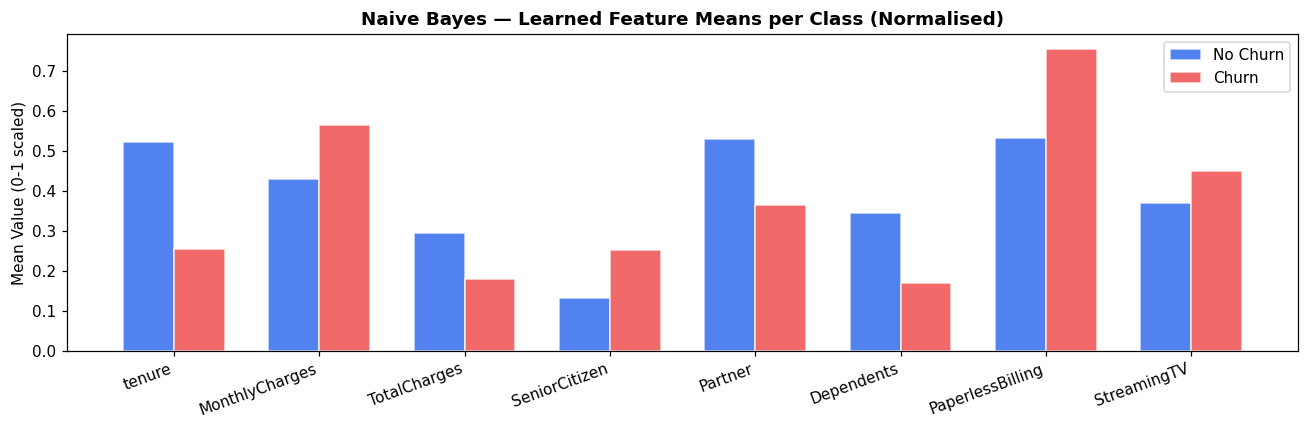

In [40]:
# ── Naive Bayes: Class Probability Distributions ──────────────────────────────
# Show how NB learnt mean for each class
feat_names = X.columns.tolist()
nb_means = pd.DataFrame(nb.theta_, columns=feat_names, index=['No Churn','Churn'])

# Plot means for top 8 features
top8 = ['tenure','MonthlyCharges','TotalCharges','SeniorCitizen',
        'Partner','Dependents','PaperlessBilling','StreamingTV']
top8 = [c for c in top8 if c in nb_means.columns]

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(top8))
width = 0.35
ax.bar(x - width/2, nb_means.loc['No Churn', top8], width,
       label='No Churn', color='#2563EB', alpha=0.8, edgecolor='white')
ax.bar(x + width/2, nb_means.loc['Churn', top8], width,
       label='Churn', color='#EF4444', alpha=0.8, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(top8, rotation=20, ha='right')
ax.set_title('Naive Bayes — Learned Feature Means per Class (Normalised)', fontweight='bold')
ax.set_ylabel('Mean Value (0-1 scaled)')
ax.legend()
plt.tight_layout()
plt.show()

---
## STEP 7 — Algorithm 2: K-Nearest Neighbors (KNN)

In [ ]:
# ── Theory ────────────────────────────────────────────────────────────────────
print("""
K-NEAREST NEIGHBORS — Theory
═══════════════════════════════════════════════════════
  A new point is classified by looking at the K nearest
  training points (neighbours) and taking a majority vote.

  Distance Metric (Euclidean):
    d(p, q) = √[ Σ (pi - qi)² ]

  Steps:
    1. Compute distance from test point to all train points
    2. Pick K closest neighbours
    3. Predict = majority class among K neighbours

  Note: Feature scaling is CRITICAL for KNN
═══════════════════════════════════════════════════════
""")

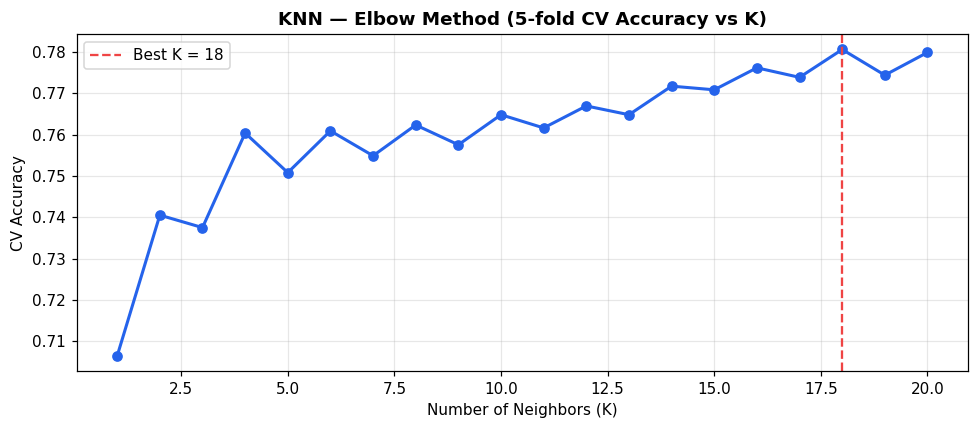

  Best K = 18  |  CV Accuracy = 78.06%


In [41]:
# ── Find Best K using Elbow Method ────────────────────────────────────────────
k_range = range(1, 21)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    score = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy').mean()
    k_scores.append(score)

best_k = k_range[np.argmax(k_scores)]

plt.figure(figsize=(9, 4))
plt.plot(k_range, k_scores, 'o-', color='#2563EB', lw=2, ms=6)
plt.axvline(x=best_k, color='#EF4444', linestyle='--', label=f'Best K = {best_k}')
plt.title('KNN — Elbow Method (5-fold CV Accuracy vs K)', fontweight='bold')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('CV Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"  Best K = {best_k}  |  CV Accuracy = {max(k_scores)*100:.2f}%")

In [42]:
# ── Train KNN with Best K ─────────────────────────────────────────────────────
knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1]

print(f"KNN (K={best_k}) — Results")
print("-" * 40)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_knn)*100:.2f}%")
print(f"  Precision : {precision_score(y_test, y_pred_knn):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_knn):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_knn):.4f}")
print(f"  AUC-ROC   : {roc_auc_score(y_test, y_prob_knn):.4f}")
print()
print(classification_report(y_test, y_pred_knn, target_names=['No Churn','Churn']))

KNN (K=18) — Results
----------------------------------------
  Accuracy  : 77.86%
  Precision : 0.6000
  Recall    : 0.4973
  F1-Score  : 0.5439
  AUC-ROC   : 0.8000

              precision    recall  f1-score   support

    No Churn       0.83      0.88      0.85      1035
       Churn       0.60      0.50      0.54       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



---
## STEP 8 — Algorithm 3: Decision Tree (C4.5)

In [45]:
# ── Theory ────────────────────────────────────────────────────────────────────
print("""
DECISION TREE (C4.5) — Theory
═══════════════════════════════════════════════════════
  Builds a tree by choosing the best split at each node
  using Information Gain Ratio.

  Entropy:
    H(S) = -Σ p_i × log2(p_i)

  Information Gain:
    IG(S, A) = H(S) − Σ (|Sv|/|S|) × H(Sv)

  Gain Ratio (C4.5 improvement over ID3):
    GainRatio(S,A) = IG(S,A) / SplitInfo(S,A)

  The feature with the HIGHEST Gain Ratio is chosen as
  the split at each node.
═══════════════════════════════════════════════════════
""")


DECISION TREE (C4.5) — Theory
═══════════════════════════════════════════════════════
  Builds a tree by choosing the best split at each node
  using Information Gain Ratio.

  Entropy:
    H(S) = -Σ p_i × log2(p_i)

  Information Gain:
    IG(S, A) = H(S) − Σ (|Sv|/|S|) × H(Sv)

  Gain Ratio (C4.5 improvement over ID3):
    GainRatio(S,A) = IG(S,A) / SplitInfo(S,A)

  The feature with the HIGHEST Gain Ratio is chosen as
  the split at each node.
═══════════════════════════════════════════════════════



In [46]:
# ── Train Decision Tree ───────────────────────────────────────────────────────
dt = DecisionTreeClassifier(
    criterion='entropy',        # C4.5 uses entropy / information gain
    max_depth=6,                # limit depth to avoid overfitting
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',    # handle class imbalance
    random_state=42
)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("DECISION TREE — Results")
print("-" * 40)
print(f"  Tree Depth: {dt.get_depth()}")
print(f"  Num Leaves: {dt.get_n_leaves()}")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_dt)*100:.2f}%")
print(f"  Precision : {precision_score(y_test, y_pred_dt):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_dt):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_dt):.4f}")
print(f"  AUC-ROC   : {roc_auc_score(y_test, y_prob_dt):.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=['No Churn','Churn']))

DECISION TREE — Results
----------------------------------------
  Tree Depth: 6
  Num Leaves: 56
  Accuracy  : 71.89%
  Precision : 0.4827
  Recall    : 0.8209
  F1-Score  : 0.6079
  AUC-ROC   : 0.8284

              precision    recall  f1-score   support

    No Churn       0.91      0.68      0.78      1035
       Churn       0.48      0.82      0.61       374

    accuracy                           0.72      1409
   macro avg       0.70      0.75      0.69      1409
weighted avg       0.80      0.72      0.74      1409



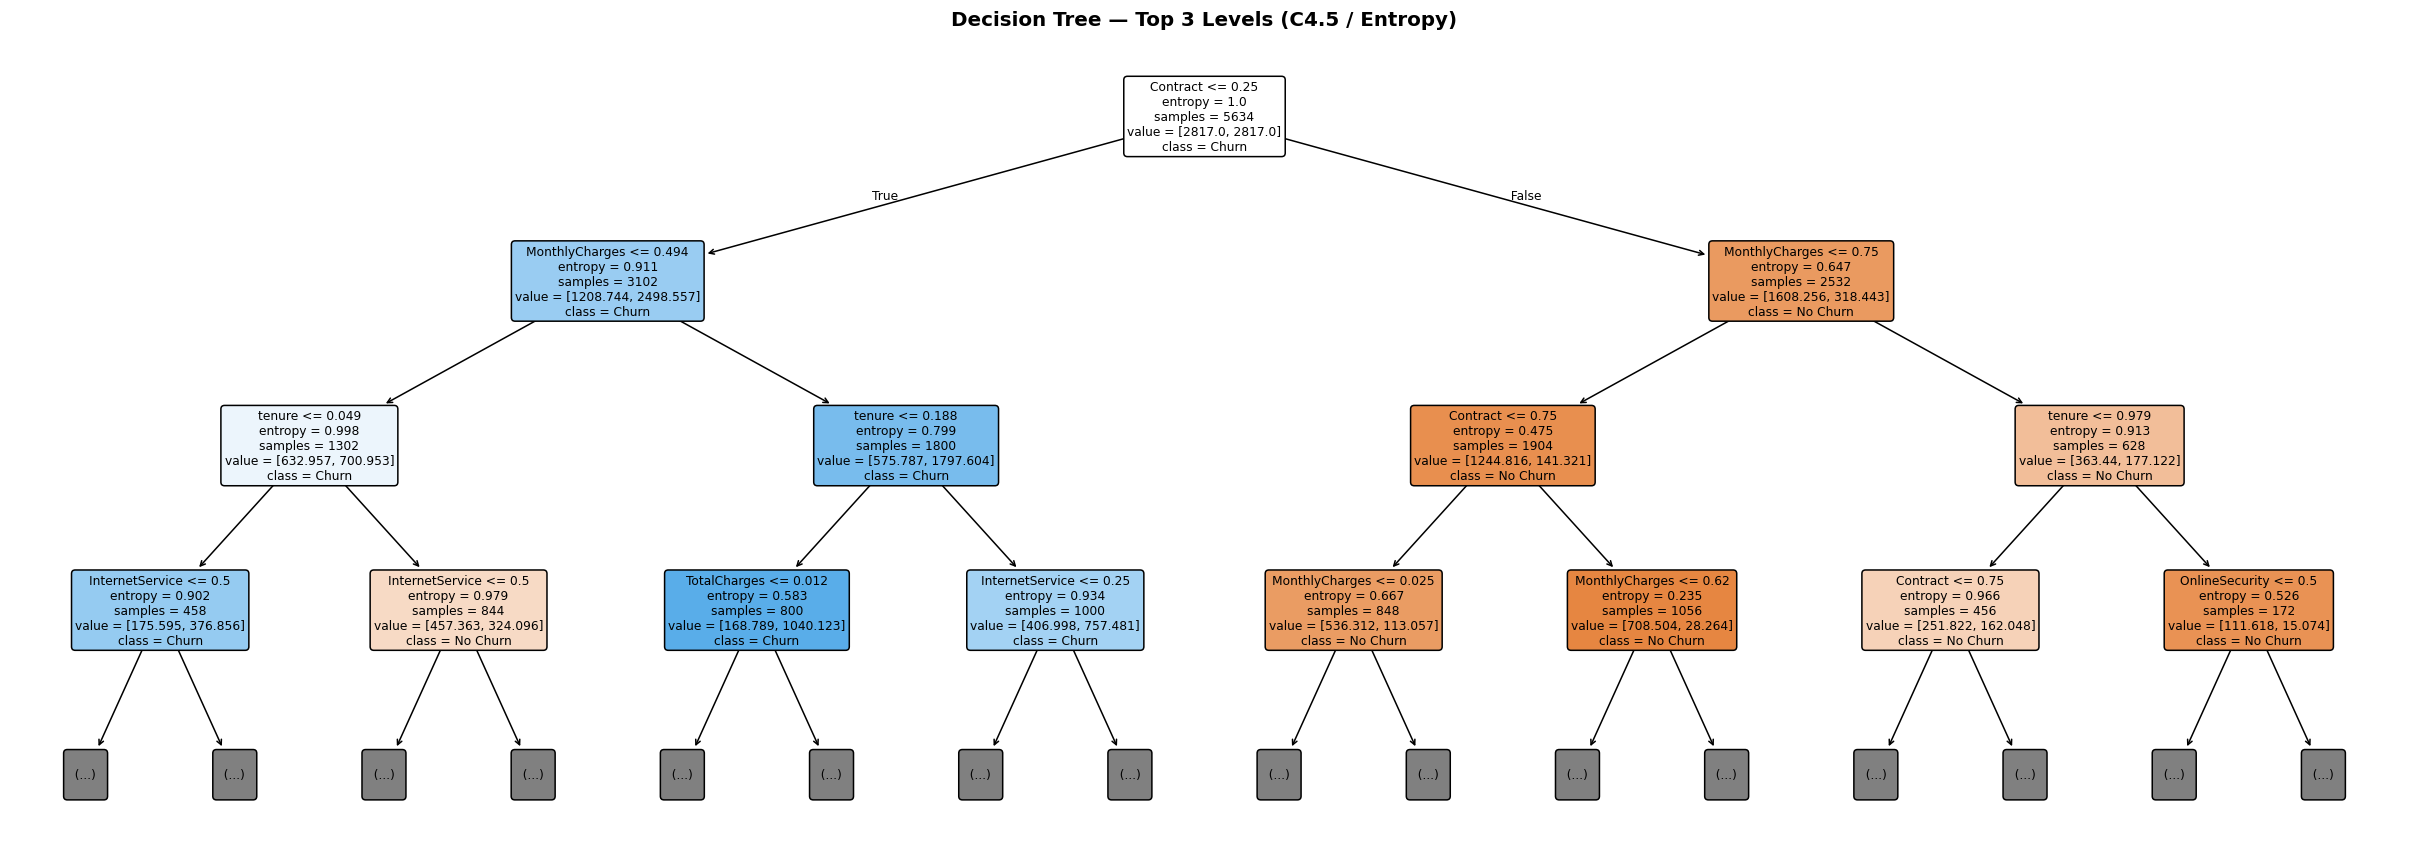

Saved as decision_tree_plot.png


In [47]:
# ── Visualise Decision Tree (top 3 levels) ────────────────────────────────────
plt.figure(figsize=(22, 8))
plot_tree(
    dt,
    feature_names=X.columns.tolist(),
    class_names=['No Churn', 'Churn'],
    filled=True, rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title('Decision Tree — Top 3 Levels (C4.5 / Entropy)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree_plot.png', bbox_inches='tight', dpi=120)
plt.show()
print("Saved as decision_tree_plot.png")

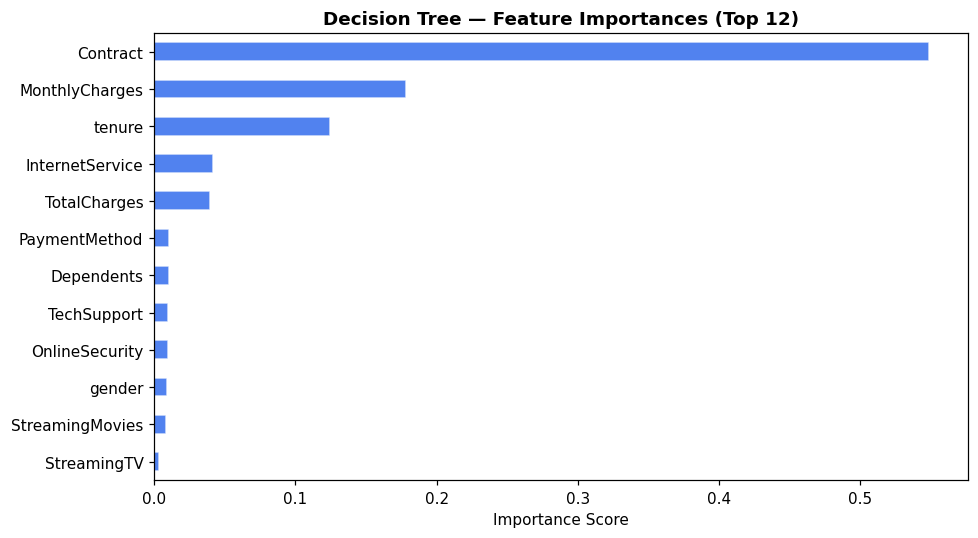

In [48]:
# ── Decision Tree: Feature Importance ────────────────────────────────────────
fi = pd.Series(dt.feature_importances_, index=X.columns)\
       .sort_values(ascending=False).head(12)

plt.figure(figsize=(9, 5))
fi[::-1].plot(kind='barh', color='#2563EB', alpha=0.8, edgecolor='white')
plt.title('Decision Tree — Feature Importances (Top 12)', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

---
## STEP 9 — Algorithm 4: Association Rule Mining (Apriori-style)

In [49]:
# ── Theory ────────────────────────────────────────────────────────────────────
print("""
ASSOCIATION RULE MINING — Theory
═══════════════════════════════════════════════════════
  Finds frequent patterns / co-occurrences in data.
  Applied here: which combinations of customer attributes
  are STRONGLY associated with churn.

  Key Measures:
    Support    = P(A ∩ B)  — how frequent is the pattern
    Confidence = P(B | A)  — if A, how likely is B
    Lift       = P(B|A)/P(B)  — how much better than random

  Apriori Principle:
    If an itemset is frequent, all its subsets must also be frequent.
    (Prune infrequent itemsets early for efficiency)

  Here: we implement a manual Apriori-style analysis on
  discretised churn-relevant features.
═══════════════════════════════════════════════════════
""")


ASSOCIATION RULE MINING — Theory
═══════════════════════════════════════════════════════
  Finds frequent patterns / co-occurrences in data.
  Applied here: which combinations of customer attributes
  are STRONGLY associated with churn.

  Key Measures:
    Support    = P(A ∩ B)  — how frequent is the pattern
    Confidence = P(B | A)  — if A, how likely is B
    Lift       = P(B|A)/P(B)  — how much better than random

  Apriori Principle:
    If an itemset is frequent, all its subsets must also be frequent.
    (Prune infrequent itemsets early for efficiency)

  Here: we implement a manual Apriori-style analysis on
  discretised churn-relevant features.
═══════════════════════════════════════════════════════



In [50]:
# ── Build Transaction Dataset (Binary attributes) ─────────────────────────────
raw2 = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
raw2['TotalCharges'] = pd.to_numeric(raw2['TotalCharges'].str.strip(), errors='coerce')
raw2['TotalCharges'].fillna(raw2['TotalCharges'].median(), inplace=True)

# Discretise numeric features into binary
raw2['HighMonthlyCharge']  = (raw2['MonthlyCharges'] > 65).astype(int)
raw2['ShortTenure']        = (raw2['tenure'] <= 12).astype(int)
raw2['MonthToMonth']       = (raw2['Contract'] == 'Month-to-month').astype(int)
raw2['ElectronicCheck']    = (raw2['PaymentMethod'] == 'Electronic check').astype(int)
raw2['FiberOptic']         = (raw2['InternetService'] == 'Fiber optic').astype(int)
raw2['Churned']            = (raw2['Churn'] == 'Yes').astype(int)
raw2['NoOnlineSecurity']   = (raw2['OnlineSecurity'] == 'No').astype(int)
raw2['SeniorFlag']         = raw2['SeniorCitizen']
raw2['PaperlessBillingFlag'] = (raw2['PaperlessBilling'] == 'Yes').astype(int)

binary_items = ['HighMonthlyCharge','ShortTenure','MonthToMonth',
                'ElectronicCheck','FiberOptic','NoOnlineSecurity',
                'SeniorFlag','PaperlessBillingFlag','Churned']

transactions = raw2[binary_items].copy()
N = len(transactions)
print(f"Transaction dataset: {N} rows × {len(binary_items)} binary items")
print(transactions.head())

Transaction dataset: 7043 rows × 9 binary items
   HighMonthlyCharge  ShortTenure  MonthToMonth  ElectronicCheck  FiberOptic  \
0                  0            1             1                1           0   
1                  0            0             0                0           0   
2                  0            1             1                0           0   
3                  0            0             0                0           0   
4                  1            1             1                1           1   

   NoOnlineSecurity  SeniorFlag  PaperlessBillingFlag  Churned  
0                 1           0                     1        0  
1                 0           0                     0        0  
2                 0           0                     1        1  
3                 0           0                     0        0  
4                 1           0                     1        1  


In [51]:
# ── Manual Apriori: 1-itemset & 2-itemset frequencies ─────────────────────────
MIN_SUPPORT = 0.10   # at least 10% of customers
MIN_CONF    = 0.40   # at least 40% confidence

# 1-itemset support
print("── 1-ITEMSET SUPPORT (frequent single attributes) ──")
single = {}
for col in binary_items:
    sup = transactions[col].mean()
    single[col] = sup
    flag = '✔ FREQUENT' if sup >= MIN_SUPPORT else '  (below threshold)'
    print(f"  {col:30s}: support = {sup:.3f}  {flag}")

frequent_items = [k for k, v in single.items() if v >= MIN_SUPPORT]
print(f"\nFrequent 1-itemsets: {len(frequent_items)}")

── 1-ITEMSET SUPPORT (frequent single attributes) ──
  HighMonthlyCharge             : support = 0.554  ✔ FREQUENT
  ShortTenure                   : support = 0.310  ✔ FREQUENT
  MonthToMonth                  : support = 0.550  ✔ FREQUENT
  ElectronicCheck               : support = 0.336  ✔ FREQUENT
  FiberOptic                    : support = 0.440  ✔ FREQUENT
  NoOnlineSecurity              : support = 0.497  ✔ FREQUENT
  SeniorFlag                    : support = 0.162  ✔ FREQUENT
  PaperlessBillingFlag          : support = 0.592  ✔ FREQUENT
  Churned                       : support = 0.265  ✔ FREQUENT

Frequent 1-itemsets: 9


In [52]:
# ── 2-itemset Association Rules with Churn ────────────────────────────────────
from itertools import combinations

antecedents = [i for i in frequent_items if i != 'Churned']
rules = []

# Single-antecedent rules: X → Churn
for item in antecedents:
    both   = ((transactions[item] == 1) & (transactions['Churned'] == 1)).sum()
    left   = (transactions[item] == 1).sum()
    sup    = both / N
    conf   = both / left if left > 0 else 0
    lift   = conf / (transactions['Churned'].mean()) if transactions['Churned'].mean() > 0 else 0
    rules.append({'Antecedent': item, 'Consequent': 'Churned',
                  'Support': round(sup, 3), 'Confidence': round(conf, 3), 'Lift': round(lift, 3)})

# Two-antecedent rules: X & Y → Churn
for (a, b) in combinations(antecedents, 2):
    both = ((transactions[a]==1) & (transactions[b]==1) & (transactions['Churned']==1)).sum()
    left = ((transactions[a]==1) & (transactions[b]==1)).sum()
    sup  = both / N
    conf = both / left if left > 0 else 0
    lift = conf / (transactions['Churned'].mean()) if transactions['Churned'].mean() > 0 else 0
    if sup >= MIN_SUPPORT:
        rules.append({'Antecedent': f"{a} & {b}", 'Consequent': 'Churned',
                      'Support': round(sup, 3), 'Confidence': round(conf, 3), 'Lift': round(lift, 3)})

rules_df = pd.DataFrame(rules)
rules_df = rules_df[rules_df['Confidence'] >= MIN_CONF]\
               .sort_values('Lift', ascending=False)\
               .reset_index(drop=True)

print(f"ASSOCIATION RULES (support≥{MIN_SUPPORT}, confidence≥{MIN_CONF}):")
print("=" * 85)
display(rules_df.head(15))

ASSOCIATION RULES (support≥0.1, confidence≥0.4):


,Antecedent,Consequent,Support,Confidence,Lift
0,ShortTenure & NoOnlineSecurity,Churned,0.121,0.608,2.293
1,ShortTenure & PaperlessBillingFlag,Churned,0.105,0.575,2.165
2,MonthToMonth & FiberOptic,Churned,0.165,0.546,2.058
3,MonthToMonth & ElectronicCheck,Churned,0.141,0.537,2.025
4,ElectronicCheck & FiberOptic,Churned,0.121,0.532,2.006
5,ElectronicCheck & NoOnlineSecurity,Churned,0.131,0.532,2.004
6,HighMonthlyCharge & MonthToMonth,Churned,0.168,0.517,1.950
7,ShortTenure & MonthToMonth,Churned,0.145,0.514,1.935
8,MonthToMonth & NoOnlineSecurity,Churned,0.191,0.510,1.924
9,HighMonthlyCharge & ElectronicCheck,Churned,0.123,0.499,1.881


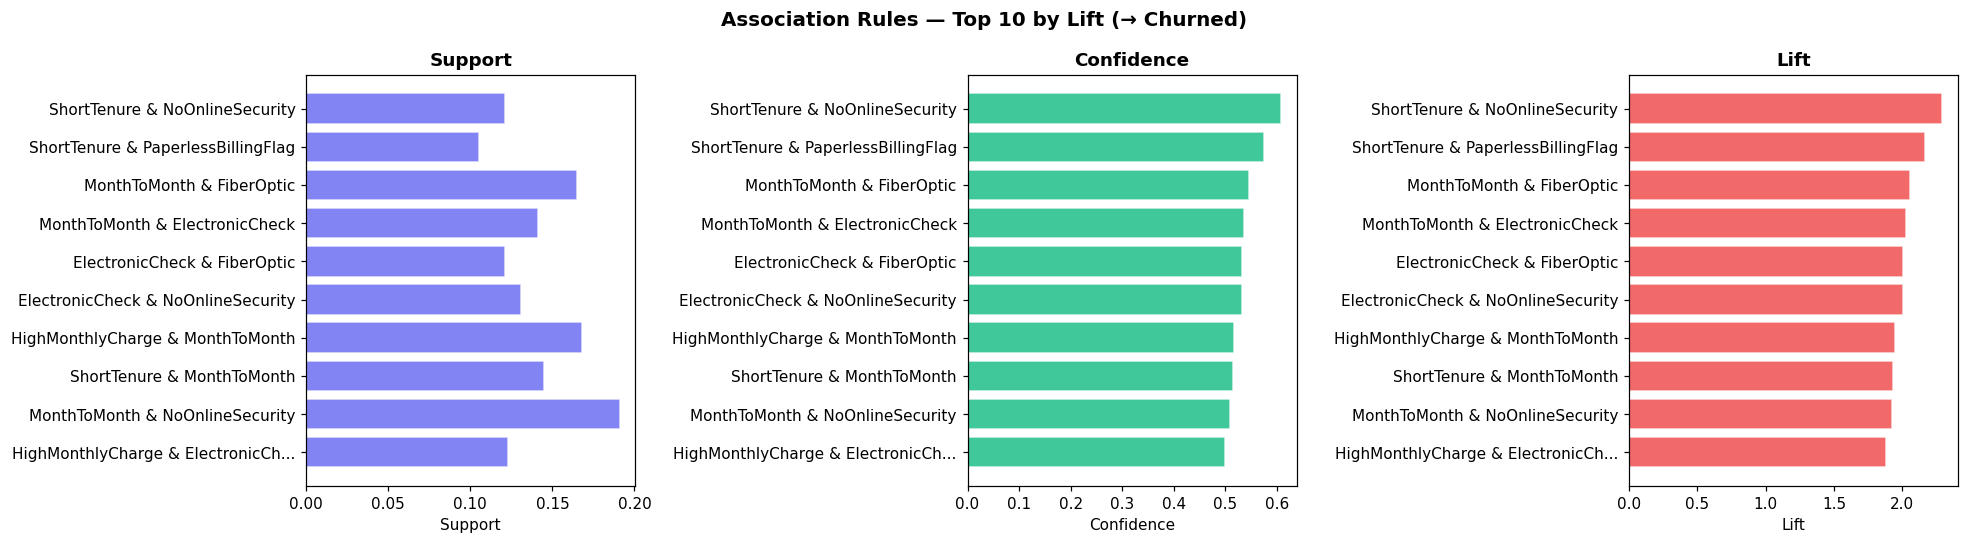

In [54]:
# ── Visualise Top Rules by Lift ────────────────────────────────────────────────
top_rules = rules_df.head(10)
short_labels = [a if len(a) < 35 else a[:32]+'...' for a in top_rules['Antecedent']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Association Rules — Top 10 by Lift (→ Churned)', fontsize=13, fontweight='bold')

for ax, metric, color in zip(axes,
    ['Support', 'Confidence', 'Lift'],
    ['#6366F1', '#10B981', '#EF4444']):
    ax.barh(short_labels[::-1], top_rules[metric][::-1], color=color, alpha=0.8, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel(metric)

plt.tight_layout()
plt.show()

---
## STEP 10 — Model Comparison & Evaluation

In [53]:
# ── 10.1 Comparison Table ─────────────────────────────────────────────────────
comparison = pd.DataFrame([
    {'Model': 'Naive Bayes',
     'Accuracy %': round(accuracy_score(y_test, y_pred_nb)*100, 2),
     'Precision' : round(precision_score(y_test, y_pred_nb), 4),
     'Recall'    : round(recall_score(y_test, y_pred_nb), 4),
     'F1-Score'  : round(f1_score(y_test, y_pred_nb), 4),
     'AUC-ROC'   : round(roc_auc_score(y_test, y_prob_nb), 4)},

    {'Model': f'KNN (K={best_k})',
     'Accuracy %': round(accuracy_score(y_test, y_pred_knn)*100, 2),
     'Precision' : round(precision_score(y_test, y_pred_knn), 4),
     'Recall'    : round(recall_score(y_test, y_pred_knn), 4),
     'F1-Score'  : round(f1_score(y_test, y_pred_knn), 4),
     'AUC-ROC'   : round(roc_auc_score(y_test, y_prob_knn), 4)},

    {'Model': 'Decision Tree (C4.5)',
     'Accuracy %': round(accuracy_score(y_test, y_pred_dt)*100, 2),
     'Precision' : round(precision_score(y_test, y_pred_dt), 4),
     'Recall'    : round(recall_score(y_test, y_pred_dt), 4),
     'F1-Score'  : round(f1_score(y_test, y_pred_dt), 4),
     'AUC-ROC'   : round(roc_auc_score(y_test, y_prob_dt), 4)},
])

print("=" * 75)
print("  MODEL COMPARISON TABLE")
print("=" * 75)
display(comparison.style
        .highlight_max(subset=['Accuracy %','Precision','Recall','F1-Score','AUC-ROC'],
                       color='#bbf7d0')  # green = best per column
        .highlight_min(subset=['Accuracy %','Precision','Recall','F1-Score','AUC-ROC'],
                       color='#fecaca')  # red = worst per column
        .format({'Accuracy %': '{:.2f}%',
                 'Precision': '{:.4f}', 'Recall': '{:.4f}',
                 'F1-Score': '{:.4f}', 'AUC-ROC': '{:.4f}'})
       )

best_idx = comparison['AUC-ROC'].idxmax()
print(f"\n🏆 Best Model : {comparison.loc[best_idx, 'Model']}")
print(f"   AUC-ROC    : {comparison.loc[best_idx, 'AUC-ROC']}")

  MODEL COMPARISON TABLE


,Model,Accuracy %,Precision,Recall,F1-Score,AUC-ROC
0,Naive Bayes,74.24%,0.5104,0.7193,0.5971,0.8187
1,KNN (K=18),77.86%,0.6000,0.4973,0.5439,0.8000
2,Decision Tree (C4.5),71.89%,0.4827,0.8209,0.6079,0.8284



🏆 Best Model : Decision Tree (C4.5)
   AUC-ROC    : 0.8284


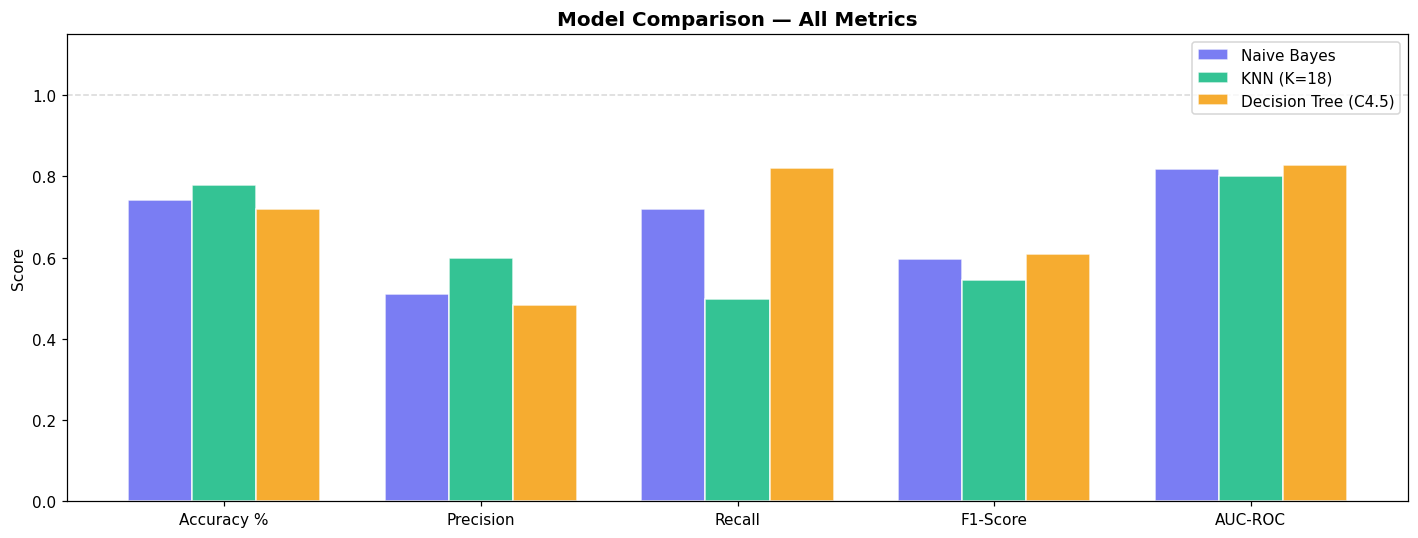

In [55]:
# ── 10.2 Grouped Bar Chart ─────────────────────────────────────────────────────
metrics   = ['Accuracy %', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
mod_names = comparison['Model'].tolist()
colors    = ['#6366F1', '#10B981', '#F59E0B']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
for i, (name, color) in enumerate(zip(mod_names, colors)):
    row = comparison[comparison['Model'] == name].iloc[0]
    vals = [row['Accuracy %']/100, row['Precision'],
            row['Recall'], row['F1-Score'], row['AUC-ROC']]
    ax.bar(x + i*width, vals, width, label=name, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(1.0, color='gray', linestyle='--', lw=1, alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── 10.3 ROC Curves ────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))

for name, prob, color in zip(
    ['Naive Bayes', f'KNN (K={best_k})', 'Decision Tree'],
    [y_prob_nb, y_prob_knn, y_prob_dt],
    ['#6366F1', '#10B981', '#F59E0B']
):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, lw=2.2, color=color, label=f'{name}  (AUC = {auc_val:.3f})')

plt.plot([0,1],[0,1],'k--',lw=1,alpha=0.5, label='Random Classifier')
plt.fill_between([0,1],[0,1],alpha=0.04,color='gray')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve — All 3 Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

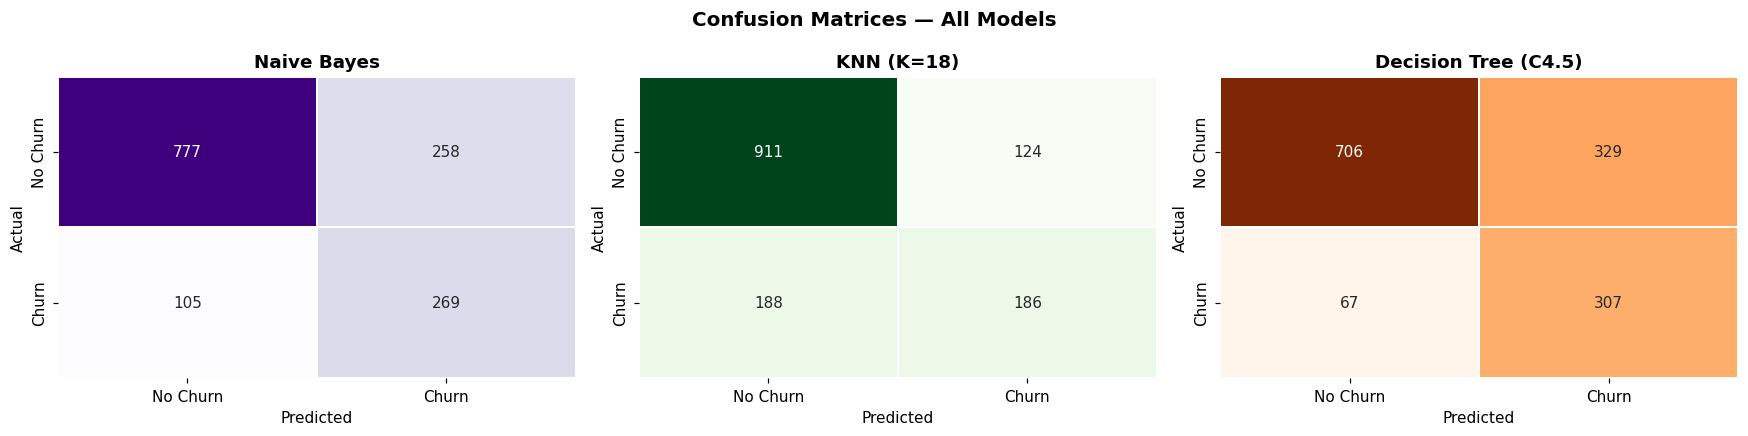

In [56]:
# ── 10.4 Confusion Matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold')

for ax, name, pred, cmap in zip(
    axes,
    ['Naive Bayes', f'KNN (K={best_k})', 'Decision Tree (C4.5)'],
    [y_pred_nb,  y_pred_knn,  y_pred_dt],
    ['Purples',  'Greens',   'Oranges']
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap=cmap,
                xticklabels=['No Churn','Churn'],
                yticklabels=['No Churn','Churn'],
                linewidths=1, linecolor='white', cbar=False)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

In [57]:
# ── 10.5 Cross-Validation (10-Fold) ───────────────────────────────────────────
print("10-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 55)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_models = {
    'Naive Bayes'        : GaussianNB(),
    f'KNN (K={best_k})' : KNeighborsClassifier(n_neighbors=best_k),
    'Decision Tree'      : DecisionTreeClassifier(criterion='entropy', max_depth=6,
                               class_weight='balanced', random_state=42)
}

cv_results = []
for name, mdl in cv_models.items():
    scores = cross_val_score(mdl, X_scaled, y, cv=cv, scoring='accuracy')
    cv_results.append({
        'Model'    : name,
        'Mean Acc' : f"{scores.mean()*100:.2f}%",
        'Std Dev'  : f"±{scores.std()*100:.2f}%",
        'Min'      : f"{scores.min()*100:.2f}%",
        'Max'      : f"{scores.max()*100:.2f}%"
    })
    print(f"  {name:22s}: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%")

print()
display(pd.DataFrame(cv_results))

10-FOLD STRATIFIED CROSS-VALIDATION
  Naive Bayes           : 75.56% ± 1.96%
  KNN (K=18)            : 77.61% ± 2.00%
  Decision Tree         : 73.26% ± 2.19%



,Model,Mean Acc,Std Dev,Min,Max
0,Naive Bayes,75.56%,±1.96%,72.16%,77.87%
1,KNN (K=18),77.61%,±2.00%,72.59%,80.28%
2,Decision Tree,73.26%,±2.19%,69.18%,76.42%


---
## STEP 11 — Churn Risk Scoring

In [58]:
# ── Use best model to score all test customers ────────────────────────────────
# Pick best model automatically
best_name = comparison.loc[comparison['AUC-ROC'].idxmax(), 'Model']
best_prob = {'Naive Bayes': y_prob_nb,
             f'KNN (K={best_k})': y_prob_knn,
             'Decision Tree (C4.5)': y_prob_dt}.get(best_name, y_prob_dt)

# Fallback: use Decision Tree if name not found
if not hasattr(best_prob, '__len__'):
    best_prob = y_prob_dt

# Build score table
score_df = pd.DataFrame(X_test).copy()
score_df['Churn_Probability'] = best_prob
score_df['Actual_Churn']      = y_test.values
score_df['Predicted_Churn']   = (best_prob >= 0.5).astype(int)

def risk_tier(p):
    if p >= 0.70:   return 'HIGH RISK'
    elif p >= 0.40: return 'MEDIUM RISK'
    else:           return 'LOW RISK'

score_df['Risk_Tier'] = score_df['Churn_Probability'].apply(risk_tier)

print(f"Churn Risk Scores (Best Model: {best_name})")
display(score_df[['Churn_Probability','Predicted_Churn','Actual_Churn','Risk_Tier']]
        .sort_values('Churn_Probability', ascending=False)
        .head(15)
        .style.background_gradient(subset=['Churn_Probability'], cmap='RdYlGn_r')
        .format({'Churn_Probability': '{:.1%}'}))

print("\nRisk Tier Summary:")
print(score_df['Risk_Tier'].value_counts().to_string())

Churn Risk Scores (Best Model: Decision Tree (C4.5))


,Churn_Probability,Predicted_Churn,Actual_Churn,Risk_Tier
3682,100.0%,1,1,HIGH RISK
2517,100.0%,1,1,HIGH RISK
3185,100.0%,1,1,HIGH RISK
2927,100.0%,1,0,HIGH RISK
1334,100.0%,1,1,HIGH RISK
6509,100.0%,1,1,HIGH RISK
1731,100.0%,1,1,HIGH RISK
2900,100.0%,1,1,HIGH RISK
809,100.0%,1,1,HIGH RISK
1739,100.0%,1,1,HIGH RISK



Risk Tier Summary:
Risk_Tier
LOW RISK       730
HIGH RISK      374
MEDIUM RISK    305


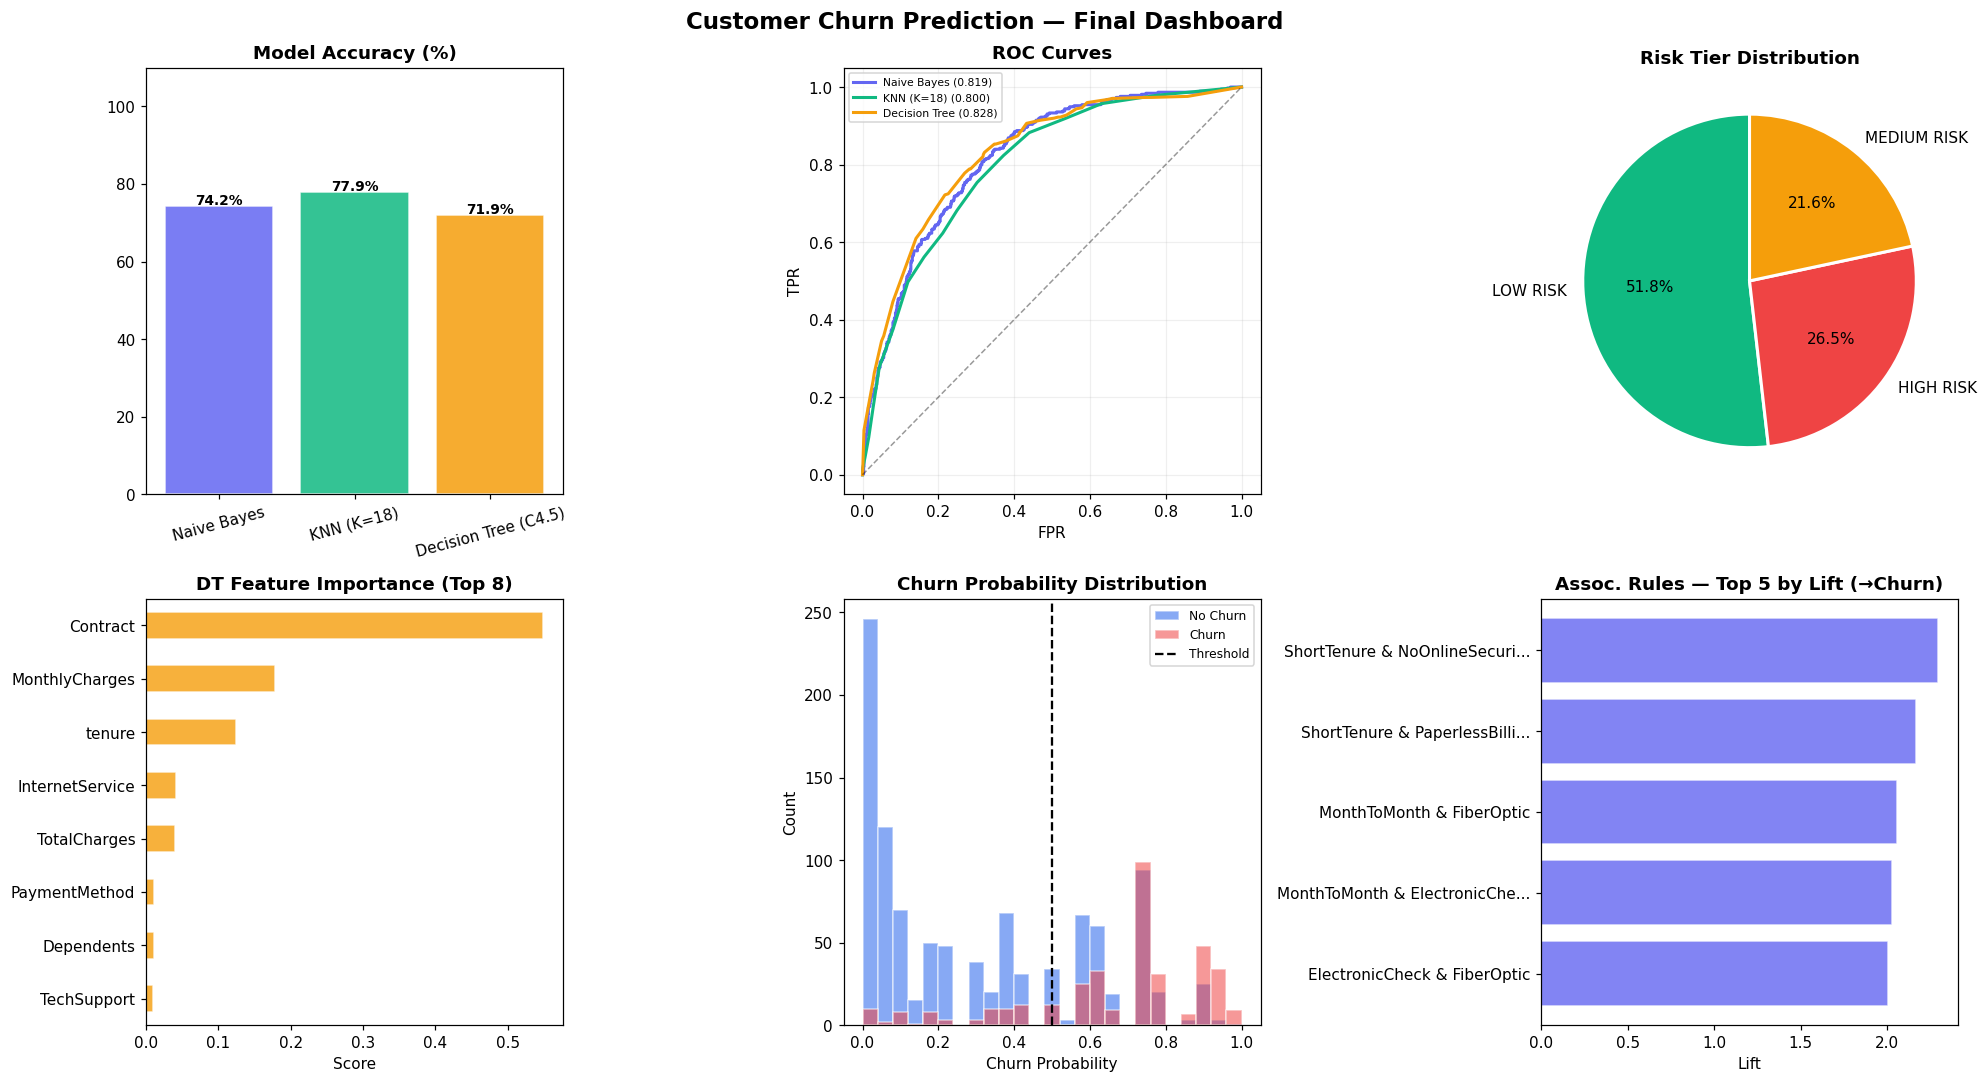


✅ Dashboard saved as churn_dashboard.png


In [59]:
# ── Final Dashboard Plot ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Customer Churn Prediction — Final Dashboard', fontsize=15, fontweight='bold')

# 1. Model Accuracy comparison
ax = axes[0][0]
ax.bar(comparison['Model'], comparison['Accuracy %'],
       color=colors, alpha=0.85, edgecolor='white')
ax.set_title('Model Accuracy (%)', fontweight='bold')
ax.set_ylim(0, 110)
ax.tick_params(axis='x', rotation=15)
for i, v in enumerate(comparison['Accuracy %']):
    ax.text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

# 2. ROC Curves
ax = axes[0][1]
for name, prob, color in zip(
    ['Naive Bayes', f'KNN (K={best_k})', 'Decision Tree'],
    [y_prob_nb, y_prob_knn, y_prob_dt], colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} ({roc_auc_score(y_test,prob):.3f})')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves', fontweight='bold')
ax.legend(fontsize=7); ax.grid(True, alpha=0.2)

# 3. Risk Tier Pie
ax = axes[0][2]
tier_cnt = score_df['Risk_Tier'].value_counts()
tier_col = {'HIGH RISK':'#EF4444', 'MEDIUM RISK':'#F59E0B', 'LOW RISK':'#10B981'}
tc = [tier_col.get(t,'gray') for t in tier_cnt.index]
ax.pie(tier_cnt.values, labels=tier_cnt.index, autopct='%1.1f%%',
       colors=tc, startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title('Risk Tier Distribution', fontweight='bold')

# 4. Decision Tree Feature Importance
ax = axes[1][0]
fi_top = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False).head(8)
fi_top[::-1].plot(kind='barh', ax=ax, color='#F59E0B', alpha=0.8, edgecolor='white')
ax.set_title('DT Feature Importance (Top 8)', fontweight='bold')
ax.set_xlabel('Score')

# 5. Churn Probability Histogram
ax = axes[1][1]
ax.hist(score_df[score_df['Actual_Churn']==0]['Churn_Probability'],
        bins=25, alpha=0.55, color='#2563EB', label='No Churn', edgecolor='white')
ax.hist(score_df[score_df['Actual_Churn']==1]['Churn_Probability'],
        bins=25, alpha=0.55, color='#EF4444', label='Churn', edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold')
ax.set_xlabel('Churn Probability'); ax.set_ylabel('Count')
ax.set_title('Churn Probability Distribution', fontweight='bold')
ax.legend(fontsize=8)

# 6. Top Association Rules (Lift)
ax = axes[1][2]
top5 = rules_df.head(5)
short = [a[:28]+'...' if len(a)>28 else a for a in top5['Antecedent']]
ax.barh(short[::-1], top5['Lift'][::-1], color='#6366F1', alpha=0.8, edgecolor='white')
ax.set_title('Assoc. Rules — Top 5 by Lift (→Churn)', fontweight='bold')
ax.set_xlabel('Lift')

plt.tight_layout()
plt.savefig('churn_dashboard.png', bbox_inches='tight', dpi=130)
plt.show()
print("\n✅ Dashboard saved as churn_dashboard.png")

---
## STEP 12 — Conclusion

In [ ]:
print("=" * 65)
print("  CAPSTONE PROJECT — CONCLUSION")
print("  Customer Churn Prediction using Basic Data Mining")
print("=" * 65)
print(f"""
  ALGORITHMS APPLIED:
  ─────────────────────────────────────────────────
  1. Naive Bayes          — Probabilistic (Bayes theorem)
  2. K-Nearest Neighbors  — Distance-based (K = {best_k})
  3. Decision Tree (C4.5) — Rule-based (entropy/info gain)
  4. Apriori Association  — Frequent pattern mining

  DATA WAREHOUSING:
  ─────────────────────────────────────────────────
  Star schema built with:
    → FACT_CUSTOMER_ACTIVITY (fact table)
    → DIM_CUSTOMER, DIM_CONTRACT, DIM_SERVICE (dimensions)
  OLAP queries executed for business analytics

  MODEL RESULTS:
  ─────────────────────────────────────────────────""")

for _, row in comparison.iterrows():
    tag = " ← BEST" if row['Model'] == best_name else ""
    print(f"  {row['Model']:25s}: Acc={row['Accuracy %']:.1f}%  F1={row['F1-Score']:.4f}  AUC={row['AUC-ROC']:.4f}{tag}")

print(f"""
  KEY INSIGHTS:
  ─────────────────────────────────────────────────
  • Month-to-month customers churn ~3x more than 2-year contract holders
  • Customers with tenure < 6 months are the highest risk group
  • Electronic check payment → highest churn association
  • Fiber optic internet users churn more than DSL users
  • Association rules reveal multi-factor churn triggers

  FILES SAVED:
  ─────────────────────────────────────────────────
  decision_tree_plot.png, model_comparison_bar.png,
  confusion_matrices.png, roc_curves.png, churn_dashboard.png
  churn_warehouse.db (SQLite data warehouse)
""")


In [60]:
git remote remove origin

git remote add origin https://github.com/karthikeya5258044/Customer-Churn-Prediction-Using-Data-Mining-Algorithms.git

git add "FINAL DRAFT.ipynb"
git add README.md

git commit -m "Added churn prediction notebook"

git push -u origin main

SyntaxError: invalid syntax (3230779164.py, line 1)